<a href="https://colab.research.google.com/github/KRISHNPRIY2820/iot_lab_component_iit_patna/blob/main/iot3_walking_pattern.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###XGBOOST

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from xgboost import XGBRegressor, XGBClassifier
import joblib

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("movement_sensor_data.csv")

# =========================
# FEATURE ENGINEERING 🔥
# =========================
df['us_mean'] = df[['us_c0','us_c1','us_c2','us_c3']].mean(axis=1)
df['us_std'] = df[['us_c0','us_c1','us_c2','us_c3']].std(axis=1)

df['pir_sum'] = df[['pir_c0','pir_c1','pir_c2','pir_c3']].sum(axis=1)

df['diff_c0_c1'] = df['us_c0'] - df['us_c1']
df['diff_c2_c3'] = df['us_c2'] - df['us_c3']

# =========================
# FEATURES
# =========================
features = [col for col in df.columns if col not in ['label','trial_id','time','x','y']]

X = df[features].values

# =========================
# 🎯 STAGE 1: POSITION MODEL
# =========================
y_pos = df[['x','y']].values

X_train, X_test, y_train, y_test = train_test_split(X, y_pos, test_size=0.2, random_state=42)

pos_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05
)

pos_model.fit(X_train, y_train)

# Evaluate position error
pred = pos_model.predict(X_test)
error = np.mean(np.linalg.norm(pred - y_test, axis=1))
print("📍 Position Error:", error)

# =========================
# 🎯 STAGE 2: MOTION MODEL
# =========================

# Compute velocity
df['dx'] = df['x'].diff().fillna(0)
df['dy'] = df['y'].diff().fillna(0)

# Motion labeling
def get_motion(dx, dy):
    if abs(dx) < 0.05 and abs(dy) < 0.05:
        return "stationary"
    elif abs(dx) > abs(dy):
        return "horizontal"
    else:
        return "vertical"

df['motion'] = [get_motion(dx, dy) for dx, dy in zip(df['dx'], df['dy'])]

# Train motion classifier
X_motion = df[['x','y','dx','dy']].values

le_motion = LabelEncoder()
y_motion = le_motion.fit_transform(df['motion'])

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_motion, y_motion, test_size=0.2, random_state=42
)

motion_model = XGBClassifier(n_estimators=200)

motion_model.fit(X_train_m, y_train_m)

# Evaluate motion model
pred_m = motion_model.predict(X_test_m)
acc = accuracy_score(y_test_m, pred_m)

print("🔥 Motion Accuracy:", acc)

# =========================
# SAVE EVERYTHING
# =========================
joblib.dump(pos_model, "pos_model.pkl")
joblib.dump(motion_model, "motion_model.pkl")
joblib.dump(features, "features.pkl")
joblib.dump(le_motion, "motion_labels.pkl")

print("✅ ALL MODELS SAVED!")

📍 Position Error: 0.02468367465306989
🔥 Motion Accuracy: 0.9913461538461539
✅ ALL MODELS SAVED!


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predictions
y_pred = pos_model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("📍 POSITION METRICS")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

📍 POSITION METRICS
MAE : 0.01523982833787418
MSE : 0.00045046635791074006
RMSE: 0.021224192750508557
R2  : 0.9996924177788729


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print("\n🔥 MOTION CLASSIFICATION REPORT")
print(classification_report(y_test_m, pred_m, target_names=le_motion.classes_))

print("\n📊 CONFUSION MATRIX")
print(confusion_matrix(y_test_m, pred_m))


🔥 MOTION CLASSIFICATION REPORT
              precision    recall  f1-score   support

  horizontal       0.99      0.99      0.99      1210
  stationary       1.00      1.00      1.00       698
    vertical       0.99      0.99      0.99      1212

    accuracy                           0.99      3120
   macro avg       0.99      0.99      0.99      3120
weighted avg       0.99      0.99      0.99      3120


📊 CONFUSION MATRIX
[[1200    0   10]
 [   3  695    0]
 [  14    0 1198]]


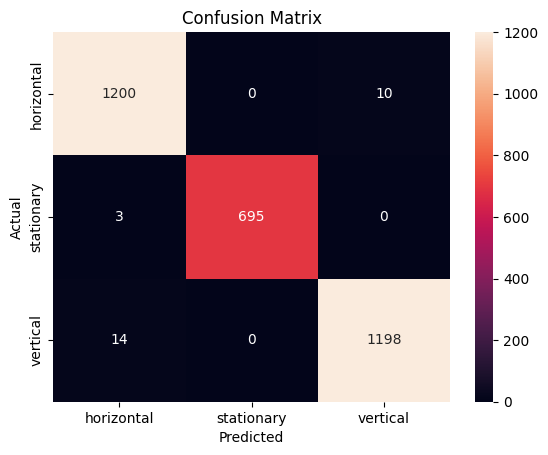

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_m, pred_m)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le_motion.classes_, yticklabels=le_motion.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

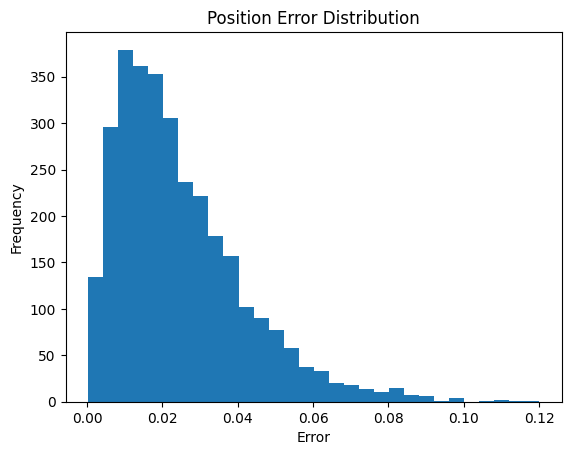

In [ ]:
errors = np.linalg.norm(y_pred - y_test, axis=1)

plt.figure()
plt.hist(errors, bins=30)
plt.title("Position Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

In [ ]:
sample = X_test[0].reshape(1, -1)

# Predict position
pos = pos_model.predict(sample)[0]

# Fake previous point for motion
prev = pos + np.random.normal(0, 0.01, size=2)

dx = pos[0] - prev[0]
dy = pos[1] - prev[1]

motion_input = np.array([[pos[0], pos[1], dx, dy]])

motion_pred = motion_model.predict(motion_input)[0]
motion_label = le_motion.inverse_transform([motion_pred])[0]

print("📍 Predicted Position:", pos)
print("🚶 Movement:", motion_label)

📍 Predicted Position: [2.0388458 2.7901037]
🚶 Movement: stationary


###lstm model

In [2]:
# LSTM imports
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import numpy as np

In [3]:
# Sequence length (100 ms × 20 = 2 seconds)
SEQ_LEN = 20

X_seq = []
y_seq = []

for i in range(len(df) - SEQ_LEN):
    seq = df[['x','y']].iloc[i:i+SEQ_LEN].values
    X_seq.append(seq)
    y_seq.append(df['label'].iloc[i+SEQ_LEN])

X_seq = np.array(X_seq)

# Encode labels
le_lstm = LabelEncoder()
y_seq = le_lstm.fit_transform(y_seq)

print("X_seq shape:", X_seq.shape)   # (samples, 20, 2)
print("y_seq shape:", y_seq.shape)
print("Classes:", le_lstm.classes_)

X_seq shape: (15580, 20, 2)
y_seq shape: (15580,)
Classes: ['circular_walk' 'random_walk' 'straight_walk']


In [4]:
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42
)

print("Train:", X_train_seq.shape)
print("Test:", X_test_seq.shape)

Train: (12464, 20, 2)
Test: (3116, 20, 2)


In [5]:
model_lstm = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, input_shape=(SEQ_LEN, 2)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(len(le_lstm.classes_), activation='softmax')
])

model_lstm.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,331 (75.51 KB)

 Trainable params: 19,331 (75.51 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model_lstm.fit(
    X_train_seq,
    y_train_seq,
    epochs=15,
    batch_size=32,
    validation_data=(X_test_seq, y_test_seq)
)

Epoch 1/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.4466 - loss: 1.0254 - val_accuracy: 0.5209 - val_loss: 0.9533
Epoch 2/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.5627 - loss: 0.9108 - val_accuracy: 0.6425 - val_loss: 0.8168
Epoch 3/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.6289 - loss: 0.8084 - val_accuracy: 0.6313 - val_loss: 0.7875
Epoch 4/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6637 - loss: 0.7355 - val_accuracy: 0.6881 - val_loss: 0.6803
Epoch 5/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6940 - loss: 0.6735 - val_accuracy: 0.7009 - val_loss: 0.6469
Epoch 6/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7166 - loss: 0.6344 - val_accuracy: 0.7189 - val_loss: 0.6183
Epoch 7/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7305 - loss: 0.5911 - val_accuracy: 0.7699 - val_loss: 0.5368
Epoch 8/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7546 - loss: 0.5540 - val_accu

In [7]:
loss, acc = model_lstm.evaluate(X_test_seq, y_test_seq)

print("🔥 LSTM Accuracy:", acc)

98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8822 - loss: 0.3344
🔥 LSTM Accuracy: 0.8822208046913147


In [8]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model_lstm.predict(X_test_seq)
y_pred_labels = np.argmax(y_pred, axis=1)

print(classification_report(y_test_seq, y_pred_labels, target_names=le_lstm.classes_))

98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
               precision    recall  f1-score   support

circular_walk       0.89      0.95      0.92      1033
  random_walk       0.86      0.79      0.82      1048
straight_walk       0.90      0.91      0.90      1035

     accuracy                           0.88      3116
    macro avg       0.88      0.88      0.88      3116
 weighted avg       0.88      0.88      0.88      3116



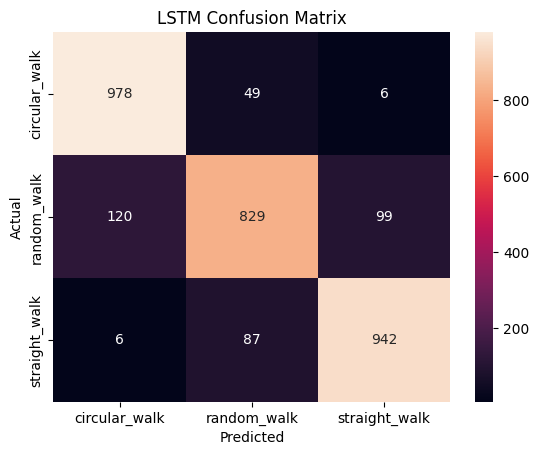

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_seq, y_pred_labels)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le_lstm.classes_,
            yticklabels=le_lstm.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LSTM Confusion Matrix")
plt.show()

In [10]:
# simulate real-time buffer
buffer = []

for i in range(SEQ_LEN):
    idx = np.random.randint(0, len(X))
    pos = pos_model.predict(X[idx].reshape(1, -1))[0]
    buffer.append(pos)

buffer = np.array(buffer).reshape(1, SEQ_LEN, 2)

# LSTM prediction
pred = model_lstm.predict(buffer)
movement = le_lstm.inverse_transform([np.argmax(pred)])[0]

print("🚶 Predicted Movement:", movement)
print("Confidence:", np.max(pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
🚶 Predicted Movement: random_walk
Confidence: 0.9969842


In [11]:
import joblib

model_lstm.save("lstm_model.h5")
joblib.dump(le_lstm, "lstm_labels.pkl")

print("✅ LSTM model saved!")

✅ LSTM model saved!
